In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from matplotlib.ticker import ScalarFormatter

# needed_moudles is a needed_modules.py script file written in .py so that it behaves as modules and function from there can be
# imported here.
from needed_modules import duty_cycle_to_kappa, von_mises_profile  

#### 1. Mock pulsar signal generator fucntion

Based on the pulse profile model given by these two equations
$$\Large{\kappa = \frac{log(2)}{2 sin^{2}(\frac{\pi D}{2})}}..............(i)$$
$$ \Large{\phi = \phi_{0} + \omega_{0}*t + \frac{1}{2}\alpha*t^2} ..............(ii)$$
$$  \Large{ \rho(\phi) = e^{-2ksin^2({\frac{\phi}{2}})}}..............(iii)$$


 One has to give a right file location to save the text data file generated.

In [2]:
def duty_cycle_to_kappa(D: float) -> float:
    """
    Use eqn(i) above to find concentration parameter(K) kappa for given value of duty cycle(D).
    """
    return np.log(2.0)/(2.0 * (np.sin((np.pi*D)/2.0))**2)

    

def phase_model(phi0 : float, omega0 : float, t : np.ndarray, alpha : float) -> np.ndarray:
    
    """ Using phase model equation above this func calculates phase model for given initial phase(p0), initial angular freq(w0),
    angular acceleration(alpha) and at given time array(t)."""
    
    phi = phi0 + omega0*t + 0.5*alpha*(t**2)
    return phi
    

def von_mises_profile(phi: np.ndarray, D: float) -> np.ndarray:
    
    """
    Eqn(iii) above to calculate a von-mise profile
    """
    
    kappa  = duty_cycle_to_kappa(D)
    
    vonmis_rho = np.exp(-2*kappa*(np.sin(phi/2))**2)
    return vonmis_rho

We use this mathematical idea below to generate noise for the signal based on what signal to noise ratio(SNR) we want to use. We choose the standard deviation of the noise based on the SNR we want to use. 

$$\text{SNR} = \frac{P_{\text{signal}}}{P_{\text{noise}}} = \frac{\sigma_{\text{signal}}^2}{\sigma_{\text{noise}}^2}.........(iv)$$

$$\text{SNR}_{dB} = 10\log_{10}\left(\frac{\sigma_{\text{signal}}^2}{\sigma_{\text{noise}}^2}\right) = 20\log_{10}\left(\frac{\sigma_{\text{signal}}}{\sigma_{\text{noise}}}\right)...........(v)$$

$$\sigma_{\text{noise}} = \frac{\sigma_{\text{signal}}}{10^{\text{SNR}_{dB}/20}}.............(vi)$$

labmda function below will add noise from the normal distribution with mean 0 and standard deviation that is chosen SNR value times standard deviation of noise given by eqn. vi. Based on this random noise is generated.

In [3]:
def mock_pulsar_generator(N_sample, time_resn, phi_initial, period, phase, dty_cycl, rndm_seed, ang_accel):
   
    time_arr = np.arange(0, N_sample)*time_resn                             # time array with interval given by sampling rate  
    omega0 = (2*np.pi)/period                                    # Angular freq [w = 2pi/p]
    kappa = duty_cycle_to_kappa(dty_cycl)                               # Calculates concentration parameter for given duty cycle
    phi_t = phase_model(phi_initial, omega0, time_arr, ang_accel)           # Phase model 
    pure_signal = von_mises_profile(phi_t, dty_cycl)
    # See descritpion above
    add_gaussian_noise = lambda signal, snr_db, rng: (signal + rng.normal(0, 15*np.std(signal) / (12 ** (snr_db / 20)), size=signal.shape))
    noisy_signal = add_gaussian_noise(pure_signal, snr_db=7, rng=rndm_seed)
    return time_arr, pure_signal, noisy_signal - np.min(noisy_signal)

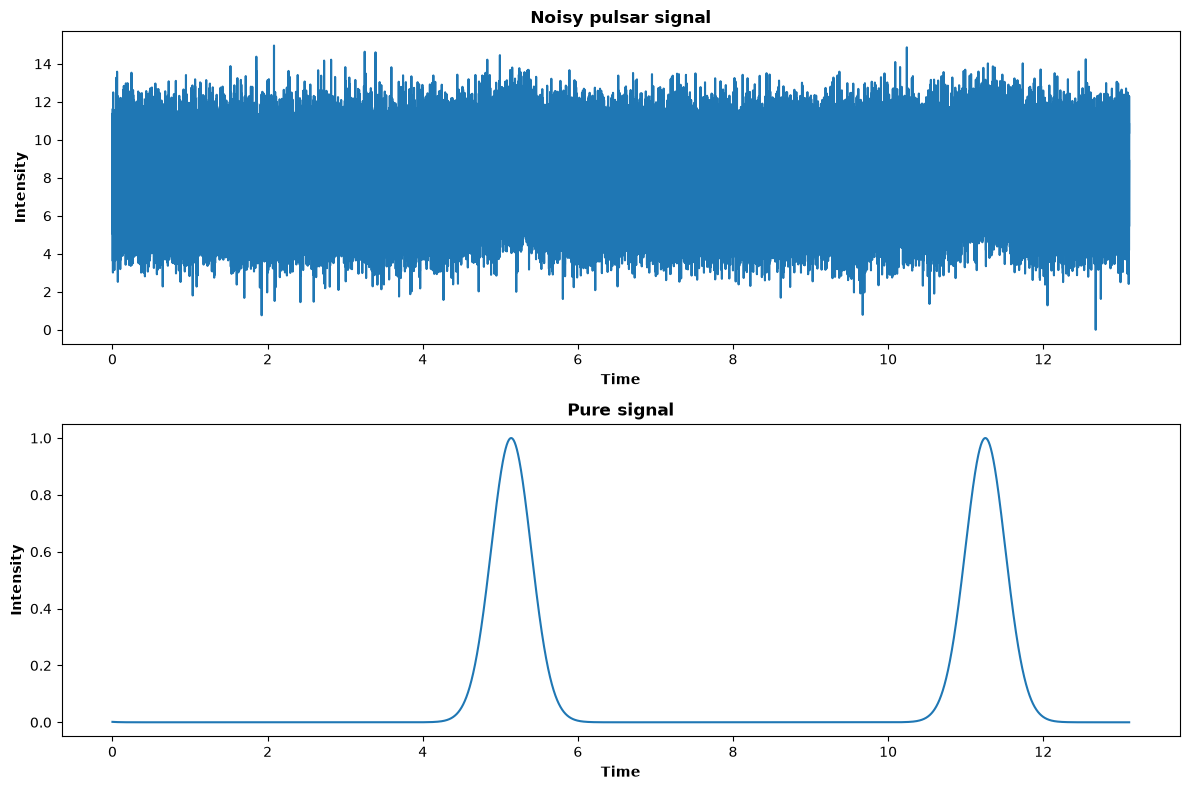

In [4]:
N_point = 2**18           # This will vary depending upon type of pulsar. 
t_sample = 50e-6          # Sampling time(in seconds) varies for different types of pulsar. millisecond for normal and microsec for msp
phase_phi = 1.0           # Keep it fixed for now.
duty_cycle = 0.1          # Duty cycle. Keep this fixed for now.
seed_val = np.random.default_rng(seed=42) # This is seed value for random number generation
filesav_path = "/Users/manojkhadka/research/claudeChatgptversion/mock_pulsar_data/"

test_period_list = [1530e-3, 2120e-3, 1785e-3, 3541e-3, 6113e-3 ]    # Input any time(in seconds) for pulsar period
ang_acceleration_list = [0, 0, 0, 0, 0]

for n in np.arange(len(test_period_list)):
    test_period = test_period_list[n]
    ang_acceleration = ang_acceleration_list[n]
    time_data, vonmise_prof_signal, mock_plsr_signal = mock_pulsar_generator(N_point, t_sample, phase_phi, test_period, phase_phi,
                                                                             duty_cycle, seed_val, ang_acceleration)
    
    time_intensity_data = np.column_stack((time_data, mock_plsr_signal))
    np.savetxt(filesav_path+"period_"+str(test_period)+"sec_"+"dty_cycl"+str(duty_cycle)+"_ang_accl_"+str(ang_acceleration)+"_.txt", 
               time_intensity_data, delimiter='\t\t',header="time\t\tintensity",comments='', fmt="%.8f")
    if len(test_period_list) - n == 1:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        ax1.plot(time_data[0::], mock_plsr_signal[0::])
        ax2.plot(time_data[0::], vonmise_prof_signal[0::])
        ax1.set_xlabel("Time", fontweight='bold')
        ax1.set_ylabel("Intensity", fontweight='bold')
        ax1.set_title("Noisy pulsar signal", fontweight='bold')
        
        ax2.set_xlabel("Time", fontweight='bold')
        ax2.set_ylabel("Intensity", fontweight='bold')
        ax2.set_title("Pure signal", fontweight='bold')
        
        plt.tight_layout()
        plt.show()

In [5]:
df = pd.read_csv(filesav_path+"period_"+str(test_period_list[0])+"sec_dty_cycl0.1_ang_accl_"+str(ang_acceleration_list[0])+"_.txt", 
                 header=0, sep='\t\t')
df.head(2)

,time,intensity
0,0.00000,8.081384
1,0.00005,6.005107


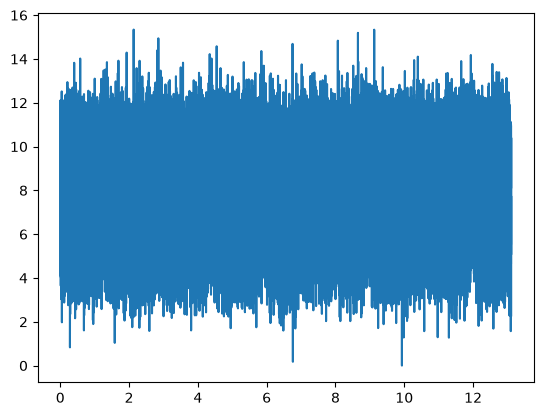

In [6]:
plt.plot(df['time'][0::], df['intensity'][0::])